<a href="https://colab.research.google.com/github/sibandze/Multimodedal-Bird-Intellegence-System/blob/main/notebooks/exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Notebook: Data Loading + Spectogram Pipeline + Exploration

---



In [9]:
import os
import pandas as pd
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

In [10]:
DATA_DIR = '../data/'
AUDIO_DOWNLOADS_DIR = os.path.join(DATA_DIR, "audio_downloads")
os.makedirs(AUDIO_DOWNLOADS_DIR, exist_ok=True)
print(f"Audio download directory created at: {AUDIO_DOWNLOADS_DIR}")

Audio download directory created at: ../data/audio_downloads


In [11]:
csv_github_url = "https://raw.githubusercontent.com/sibandze/Multimodedal-Bird-Intellegence-System/main/data/birds_voices.csv"
df = pd.read_csv(csv_github_url)

df.head()

,common_name,scientific_name,recordist_name,recording_length,Date,TYPE,xc_id,Time,Country,Download_link
0,Common Ostrich,Struthio camelus australis,Frank Lambert,0:53,2019-10-30,call,XC516153,08:05,South Africa,https://xeno-canto.org/516153/download
1,Common Ostrich,Struthio camelus,Jeremy Hegge,0:26,2014-11-20,call,XC208209,04:00,South Africa,https://xeno-canto.org/208209/download
2,Common Ostrich,Struthio camelus,Jeremy Hegge,0:04,2014-11-21,call,XC208128,06:00,South Africa,https://xeno-canto.org/208128/download
3,Common Ostrich,Struthio camelus,Derek Solomon,0:11,2010-02-09,call,XC46725,07:00,South Africa,https://xeno-canto.org/46725/download
4,Common Ostrich,Struthio camelus,Morioka Zoological Park ZOOMO,1:47,2021-09-06,"voice during egg laying, zoo collection",XC675445,17:00,Japan,https://xeno-canto.org/675445/download


In [12]:
missing_scientific_names = df['scientific_name'].isnull().sum()
print(f"Number of missing scientific names: {missing_scientific_names}")

if missing_scientific_names == 0:
    print("All entries have scientific names.")
else:
    print(f"{missing_scientific_names} entries are missing scientific names. These entries should be addressed (e.g., dropped or filled) if scientific name is a required feature.")

Number of missing scientific names: 0
All entries have scientific names.


In [13]:
# Create a mapping from scientific name to common name
scientific_to_common_name_map = df.set_index('scientific_name')['common_name'].drop_duplicates().to_dict()
print("Scientific Name to Common Name Map (first 5 entries):")
for i, (sci_name, comm_name) in enumerate(scientific_to_common_name_map.items()):
    if i >= 5: break
    print(f"  {sci_name}: {comm_name}")

# Get unique scientific names
unique_scientific_names = df['scientific_name'].unique()

# Create a dictionary to map scientific names to unique integer IDs
scientific_name_to_id = {name: i for i, name in enumerate(unique_scientific_names)}

print("\nScientific Name to ID Map (first 5 entries):")
for i, (sci_name, id_val) in enumerate(scientific_name_to_id.items()):
    if i >= 5: break
    print(f"  {sci_name}: {id_val}")

# Optionally, add the numerical ID to the DataFrame
df['scientific_name_id'] = df['scientific_name'].map(scientific_name_to_id)
display(df[['scientific_name', 'scientific_name_id']].head())

Scientific Name to Common Name Map (first 5 entries):
  Struthio camelus australis: Common Ostrich
  Struthio molybdophanes: Somali Ostrich
  Rhea americana: Greater Rhea
  Rhea pennata: Lesser Rhea
  Apteryx australis: Southern Brown Kiwi

Scientific Name to ID Map (first 5 entries):
  Struthio camelus australis: 0
  Struthio camelus: 1
  Struthio molybdophanes: 2
  Rhea americana: 3
  Rhea americana araneipes: 4


,scientific_name,scientific_name_id
0,Struthio camelus australis,0
1,Struthio camelus,1
2,Struthio camelus,1
3,Struthio camelus,1
4,Struthio camelus,1


In [14]:
num_species = len(unique_scientific_names)
print(f"Number of different species: {num_species}")

Number of different species: 219


In [15]:
import requests

def download_audio(url, filename, output_dir="./audio_downloads"):
    """
    Downloads an audio file from a given URL.

    Args:
        url (str): The URL of the audio file.
        filename (str): The desired filename for the downloaded audio.
        output_dir (str): The directory to save the downloaded audio file.

    Returns:
        str: The full path to the downloaded file, or None if download fails.
    """
    os.makedirs(output_dir, exist_ok=True)
    filepath = os.path.join(output_dir, filename)
    try:
        response = requests.get(url, stream=True)
        response.raise_for_status() # Raise an exception for HTTP errors
        with open(filepath, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Downloaded: {filepath}")
        return filepath
    except requests.exceptions.RequestException as e:
        print(f"Error downloading {url}: {e}")
        return None


In [16]:
def download_audio(url, filename, output_dir=AUDIO_DOWNLOADS_DIR):
    """
    Downloads an audio file from a given URL.

    Args:
        url (str): The URL of the audio file.
        filename (str): The desired filename for the downloaded audio.
        output_dir (str): The directory to save the downloaded audio file.

    Returns:
        str: The full path to the downloaded file, or None if download fails.
    """
    os.makedirs(output_dir, exist_ok=True)
    filepath = os.path.join(output_dir, filename)
    try:
        response = requests.get(url, stream=True)
        response.raise_for_status() # Raise an exception for HTTP errors
        with open(filepath, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Downloaded: {filepath}")
        return filepath
    except requests.exceptions.RequestException as e:
        print(f"Error downloading {url}: {e}")
        return None

In [17]:
def create_spectrogram(audio_path, sr=22050, n_fft=2048, hop_length=512):
    """
    Loads an audio file and generates its spectrogram.

    Args:
        audio_path (str): The path to the audio file.
        sr (int): Sampling rate for audio loading. Defaults to 22050.
        n_fft (int): FFT window size. Defaults to 2048.
        hop_length (int): Number of samples between successive frames. Defaults to 512.

    Returns:
        numpy.ndarray: The magnitude spectrogram.
    """
    try:
        # Load the audio file
        y, sr = librosa.load(audio_path, sr=sr)

        # Compute the Short-Time Fourier Transform (STFT)
        stft = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)

        # Convert to magnitude spectrogram
        spectrogram = librosa.amplitude_to_db(np.abs(stft), ref=np.max)

        # Display the spectrogram
        plt.figure(figsize=(10, 4))
        librosa.display.specshow(spectrogram, sr=sr, x_axis='time', y_axis='log', hop_length=hop_length)
        plt.colorbar(format='%+2.0f dB')
        plt.title('Spectrogram')
        plt.tight_layout()
        plt.show()

        return spectrogram
    except Exception as e:
        print(f"Error creating spectrogram for {audio_path}: {e}")
        return None


In [18]:
# Define directory for saving spectrograms
SPECTROGRAM_DIR = os.path.join(DATA_DIR, "spectrograms")
os.makedirs(SPECTROGRAM_DIR, exist_ok=True)
print(f"Spectrograms will be saved to: {SPECTROGRAM_DIR}")

# Modify create_spectrogram to return data and add a separate save function
def create_spectrogram_data(audio_path, sr=22050, n_fft=2048, hop_length=512):
    """
    Loads an audio file and generates its spectrogram data.

    Args:
        audio_path (str): The path to the audio file.
        sr (int): Sampling rate for audio loading. Defaults to 22050.
        n_fft (int): FFT window size. Defaults to 2048.
        hop_length (int): Number of samples between successive frames. Defaults to 512.

    Returns:
        tuple: (numpy.ndarray, int) The magnitude spectrogram data and sampling rate, or (None, None) if an error occurs.
    """
    try:
        y, sr_load = librosa.load(audio_path, sr=sr)
        stft = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
        spectrogram_data = librosa.amplitude_to_db(np.abs(stft), ref=np.max)
        return spectrogram_data, sr_load
    except Exception as e:
        print(f"Error generating spectrogram data for {audio_path}: {e}")
        return None, None

def save_spectrogram_image(spectrogram_data, sr, output_path, hop_length=512):
    """
    Saves a spectrogram numpy array as an image.

    Args:
        spectrogram_data (numpy.ndarray): The magnitude spectrogram data.
        sr (int): Sampling rate.
        output_path (str): The full path to save the spectrogram image.
        hop_length (int): Number of samples between successive frames.
    """
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(spectrogram_data, sr=sr, x_axis='time', y_axis='log', hop_length=hop_length)
    plt.colorbar(format='%+2.0f dB')
    plt.title('Spectrogram')
    plt.tight_layout()
    plt.savefig(output_path) # Save the figure
    plt.close() # Close the figure to prevent it from displaying in notebooks


Spectrograms will be saved to: ../data/spectrograms


Let's test these functions with an example. I will download the first audio file listed in your DataFrame and then generate its spectrogram.

Downloaded: ../data/audio_downloads/audio_XC516153.mp3


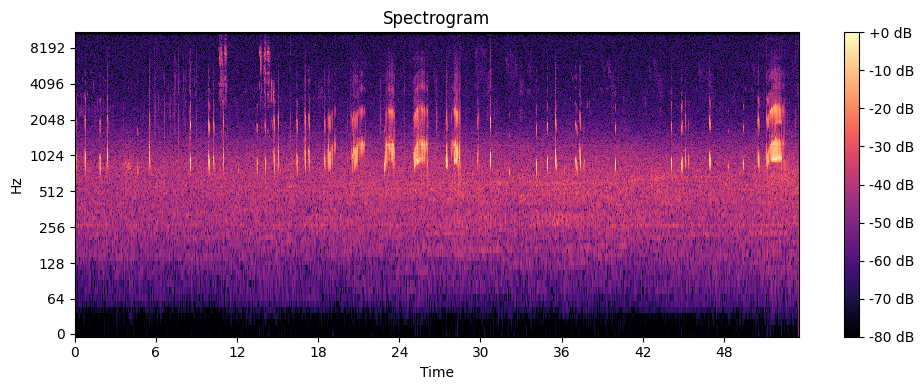

Spectrogram generated for audio_XC516153.mp3.


In [20]:
# Get the first audio download link from the DataFrame
example_url = df['Download_link'].iloc[0]
example_filename = f"audio_{df['xc_id'].iloc[0]}.mp3" # Using xc_id for filename

# Download the audio file
downloaded_filepath = download_audio(example_url, example_filename)

# If download was successful, create and display the spectrogram
if downloaded_filepath:
    spectrogram = create_spectrogram(downloaded_filepath)
    if spectrogram is not None:
        print(f"Spectrogram generated for {example_filename}.")
    else:
        print(f"Failed to generate spectrogram for {example_filename}.")
else:
    print(f"Failed to download audio from {example_url}.")

Now, let's process all audio files in the DataFrame. We will download each audio, generate its spectrogram, save both locally, and update the DataFrame.

In [ ]:
local_audio_paths = []
local_spectrogram_paths = []

for index, row in df.iterrows():
    audio_url = row['Download_link']
    xc_id = row['xc_id']
    scientific_name = row['scientific_name']

    # Generate filenames based on xc_id and scientific_name for uniqueness and clarity
    audio_filename = f"{xc_id}_{scientific_name.replace(' ', '_').replace('/', '_')}.mp3"
    spectrogram_filename = f"{xc_id}_{scientific_name.replace(' ', '_').replace('/', '_')}.png"

    downloaded_audio_path = download_audio(audio_url, audio_filename, output_dir=AUDIO_DOWNLOADS_DIR)

    if downloaded_audio_path:
        spectrogram_data, sr_loaded = create_spectrogram_data(downloaded_audio_path)
        if spectrogram_data is not None:
            spectrogram_output_path = os.path.join(SPECTROGRAM_DIR, spectrogram_filename)
            save_spectrogram_image(spectrogram_data, sr_loaded, spectrogram_output_path)
            local_audio_paths.append(downloaded_audio_path)
            local_spectrogram_paths.append(spectrogram_output_path)
            print(f"Processed {audio_filename}")
        else:
            local_audio_paths.append(downloaded_audio_path)
            local_spectrogram_paths.append(None) # Mark as failed if spectrogram not created
            print(f"Failed to create spectrogram for {audio_filename}")
    else:
        local_audio_paths.append(None) # Mark as failed if download failed
        local_spectrogram_paths.append(None)
        print(f"Failed to download audio from {audio_url}")

# Add the new paths to the DataFrame
df['local_audio_path'] = local_audio_paths
df['local_spectrogram_path'] = local_spectrogram_paths

# Display a sample of the updated DataFrame
display(df[['common_name', 'scientific_name', 'Download_link', 'local_audio_path', 'local_spectrogram_path']].head())

# Save the updated DataFrame to a new CSV file
updated_csv_path = os.path.join(DATA_DIR, 'birds_voices_with_local_paths.csv')
df.to_csv(updated_csv_path, index=False)
print(f"\nUpdated DataFrame saved to: {updated_csv_path}")

Downloaded: ../data/audio_downloads/XC516153_Struthio_camelus_australis.mp3
Processed XC516153_Struthio_camelus_australis.mp3
Downloaded: ../data/audio_downloads/XC208209_Struthio_camelus.mp3
Processed XC208209_Struthio_camelus.mp3
Downloaded: ../data/audio_downloads/XC208128_Struthio_camelus.mp3
Processed XC208128_Struthio_camelus.mp3
Downloaded: ../data/audio_downloads/XC46725_Struthio_camelus.mp3
Processed XC46725_Struthio_camelus.mp3
Error downloading https://xeno-canto.org/675445/download: 404 Client Error: Not Found for url: https://xeno-canto.org/675445/download
Failed to download audio from https://xeno-canto.org/675445/download
Downloaded: ../data/audio_downloads/XC673753_Struthio_camelus.mp3
Processed XC673753_Struthio_camelus.mp3
Downloaded: ../data/audio_downloads/XC563003_Struthio_camelus.mp3
Processed XC563003_Struthio_camelus.mp3
Downloaded: ../data/audio_downloads/XC292043_Struthio_molybdophanes.mp3
Processed XC292043_Struthio_molybdophanes.mp3
Downloaded: ../data/audio

/tmp/ipykernel_1949/1706020547.py:21: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr_load = librosa.load(audio_path, sr=sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Processed XC126083_Casuarius_casuarius.mp3
Downloaded: ../data/audio_downloads/XC404787_Casuarius_casuarius.mp3
Processed XC404787_Casuarius_casuarius.mp3
Downloaded: ../data/audio_downloads/XC316215_Casuarius_casuarius.mp3
Processed XC316215_Casuarius_casuarius.mp3
Downloaded: ../data/audio_downloads/XC316214_Casuarius_casuarius.mp3
Processed XC316214_Casuarius_casuarius.mp3
Downloaded: ../data/audio_downloads/XC276905_Casuarius_casuarius.mp3
Processed XC276905_Casuarius_casuarius.mp3
Downloaded: ../data/audio_downloads/XC158488_Casuarius_casuarius.mp3
Processed XC158488_Casuarius_casuarius.mp3
Downloaded: ../data/audio_downloads/XC143429_Casuarius_casuarius.mp3
Processed XC143429_Casuarius_casuarius.mp3
Downloaded: ../data/audio_downloads/XC140150_Casuarius_casuarius.mp3
Processed XC140150_Casuarius_casuarius.mp3
Downloaded: ../data/audio_downloads/XC132934_Casuarius_casuarius.mp3
Processed XC132934_Casuarius_casuarius.mp3
Downloaded: ../data/audio_downloads/XC125292_Casuarius_casuar